# Aula 10 - Avaliação de Modelos - Parte 1 (Validação Cruzada, Curvas ROC & AUC)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 09, conhecemos algoritmos de alta capacidade como Árvores de Decisão, Random Forest e SVM. Mas modelos poderosos podem facilmente nos iludir com boas notas causadas por sorte na amostragem ou por desbalanceamento severo de classes.
> 🎯 **Objetivo Principal da Aula:** Blindar a avaliação de modelos com técnicas estatísticas robustas: aplicar **Validação Cruzada (K-Fold e Stratified K-Fold)**, analisar o trade-off entre sensibilidade e especificidade com a **Curva ROC**, calcular a métrica **AUC (Area Under Curve)** e compreender o ajuste fino do limiar de probabilidade.
> 🚀 **Para onde vamos:** Na próxima aula ('Avaliação de Modelos - Parte 2'), usaremos essas métricas robustas para resolver outro grande desafio: como encontrar automaticamente a melhor combinação de hiperparâmetros (número de árvores, profundidade, penalidades) sem precisar chutar na mão?

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & Os Riscos do Train/Test Split** | Por que uma única divisão treino/teste pode gerar sorte amostral e o conceito de Validação Cruzada ($K$-Fold). |
| **Módulo 2** | **Curvas ROC / AUC & Ajuste do Limiar (Threshold)** | Taxa de Verdadeiros Positivos (TPR) vs Falsos Positivos (FPR), o significado do AUC e variação do threshold. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 7 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Validação cruzada com variação de dobras $K$ em dataset de risco de crédito. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & Validação Cruzada

### 1.1 O Perigo de Confiar em uma Única Divisão Treino/Teste
Até aqui, usamos o `train_test_split` dividindo os dados uma única vez. No entanto, se o conjunto de teste der a "sorte" de conter apenas exemplos fáceis, o modelo parecerá incrível; se contiver amostras difíceis, parecerá péssimo.

A **Validação Cruzada K-Fold ($K$-Fold Cross-Validation)** elimina essa incerteza amostral dividindo os dados em $K$ partes (dobras/folds) iguais:

```mermaid
graph TD
    subgraph Validação Cruzada 5-Fold
    A1["Dobra 1: TESTE | Dobras 2,3,4,5: TREINO -> Acurácia 1 = 92%"]
    A2["Dobra 2: TESTE | Dobras 1,3,4,5: TREINO -> Acurácia 2 = 89%"]
    A3["Dobra 3: TESTE | Dobras 1,2,4,5: TREINO -> Acurácia 3 = 94%"]
    A4["Dobra 4: TESTE | Dobras 1,2,3,5: TREINO -> Acurácia 4 = 91%"]
    A5["Dobra 5: TESTE | Dobras 1,2,3,4: TREINO -> Acurácia 5 = 93%"]
    end
    A1 & A2 & A3 & A4 & A5 --> B["📊 MÉDIA FINAL ROBUSTA: 91.8% ± 1.7%"]
```

> [!TIP]
> 🖖 **Analogia Geek — O Teste Kobayashi Maru de Star Trek:**
> Submeter um modelo a uma única divisão treino/teste é como fazer uma simulação simples. A **Validação Cruzada $K$-Fold** é o teste *Kobayashi Maru*: ela testa a resistência do algoritmo sob TODAS as variações possíveis de cenários para garantir que ele não entre em colapso no espaço real!

> [!NOTE]
> 💡 **Curiosidade da Aula — A Origem Militar do Nome "Curva ROC":**
> A Curva ROC (Receiver Operating Characteristic) foi criada durante a **Segunda Guerra Mundial pelos operadores de RADAR britânicos e americanos**. Eles precisavam medir a capacidade dos radaristas de diferenciar sinal real (aviões inimigos se aproximando = Verdadeiros Positivos) de ruídos e interferências (bandos de pássaros = Falsos Positivos). Mais tarde, a medicina e a inteligência artificial adotaram o mesmo gráfico!  
> 🎥 **Vídeo Recomendado:** [StatQuest: ROC and AUC (YouTube)](https://www.youtube.com/watch?v=4jRBRDbJemM)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** A Validação Cruzada K-Fold divide os dados em K pedaços e treina K vezes, garantindo que todo o dataset seja usado tanto no treino quanto no teste para evitar a "sorte amostral".

---

## Módulo 2: O Mecanismo por Dentro & Curva ROC e AUC

### 2.1 A Curva ROC e a Métrica AUC
A **Curva ROC** avalia o desempenho de um classificador probabilístico em **todos os limiares de decisão possíveis** (de $0.0$ a $1.0$).

- **Eixo Y:** Taxa de Verdadeiros Positivos / Recall / Sensibilidade ($\text{TPR} = \frac{VP}{VP + FN}$).
- **Eixo X:** Taxa de Falsos Positivos ($\text{FPR} = \frac{FP}{FP + VN}$).
- **AUC (Área Sob a Curva):** Quantifica o gráfico em um único número de $0.0$ a $1.0$:
  - $\text{AUC} = 0.50$: Modelo chuta aleatoriamente (igual a jogar moeda).
  - $\text{AUC} = 0.80 - 0.90$: Bom classificador.
  - $\text{AUC} = 1.00$: Classificador Perfeito!

> [!IMPORTANT]
> 💡 **Em 1 Frase:** A Curva ROC plota o equilíbrio entre os acertos (TPR) e alarmes falsos (FPR), e a pontuação AUC mede a capacidade global do modelo em separar as duas classes (sendo 1.0 a perfeição).

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** até aqui avaliamos um modelo em uma divisão de treino e teste. Agora vamos observar a avaliação por vários recortes dos dados. Antes de focar nas siglas, guarde a ideia central: validação cruzada verifica se o resultado se mantém estável; ROC e AUC mostram como o modelo separa as classes em diferentes limiares.

---

### Bloco 3.1 — Importando Bibliotecas e Carregando o Dataset Médico

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que contêm os dados de `load_breast_cancer`?**  
> Contêm 569 amostras de biópsias de tumores com 30 características clínicas (ex: raio, textura, área) e rótulos indicando se o tumor é Maligno (1) ou Benigno (0).

In [1]:
# 1. Importamos as bibliotecas de processamento numérico e gráfico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. Importamos o dataset médico de diagnóstico de câncer do Scikit-Learn
from sklearn.datasets import load_breast_cancer

# 3. Importamos os utilitários de validação cruzada, divisão e padronização
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

# 4. Carregamos o objeto bruto de dados
dados_brutos_cancer = load_breast_cancer()
matriz_entradas_medicas = dados_brutos_cancer.data
vetor_respostas_medicas = dados_brutos_cancer.target

# 5. Exibimos a confirmação de carregamento
print("--- DATASET MÉDICO CARREGADO ---")
print(f"📐 Dimensão do Dataset: {matriz_entradas_medicas.shape} (569 pacientes, 30 variáveis médicas)")

--- DATASET MÉDICO CARREGADO ---
📐 Dimensão do Dataset: (569, 30) (569 pacientes, 30 variáveis médicas)


---

### Bloco 3.2 — Executando Validação Cruzada 5-Fold (`cross_val_score`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que o parâmetro `cv=5` faz exatamente?**  
> Ele divide o dataset em 5 partes iguais, treina o modelo 5 vezes (usando 4 partes para treino e 1 para teste em cada rodada) e retorna as 5 pontuações individuais de acurácia.

In [2]:
# 1. Instanciamos a Regressão Logística com limite alto de iterações para garantir convergência
modelo_logistico = LogisticRegression(max_iter=5000, random_state=42)

# 2. Executamos a validação cruzada 5-Fold nos dados completos
pontuacoes_validacao_cruzada = cross_val_score(
    modelo_logistico, 
    matriz_entradas_medicas, 
    vetor_respostas_medicas, 
    cv=5, 
    scoring='accuracy'
)

# 3. Exibimos o relatório com as 5 acurácias, a média e o desvio padrão no console
print("--- RESULTADOS DA VALIDAÇÃO CRUZADA (5-FOLD) ---")
print(f"Pontuações das 5 dobras: {pontuacoes_validacao_cruzada.round(4)}")
print(f"📊 Acurácia Média Final: {pontuacoes_validacao_cruzada.mean() * 100:.2f}% ± {pontuacoes_validacao_cruzada.std() * 100:.2f}%")

--- RESULTADOS DA VALIDAÇÃO CRUZADA (5-FOLD) ---
Pontuações das 5 dobras: [0.9386 0.9474 0.9825 0.9298 0.9558]
📊 Acurácia Média Final: 95.08% ± 1.80%


---

### Bloco 3.3 — Executando Stratified K-Fold Recomendado para Manter Proporções

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Qual a diferença entre `KFold` e `StratifiedKFold`?**  
> O `StratifiedKFold` embaralha e garante que a proporção exata de tumores malignos/benignos seja idêntica em cada uma das 5 dobras, sendo o método ideal para problemas de classificação.

In [3]:
# 1. Criamos a estrutura do validador estratificado com 5 dobras e embaralhamento ativo
validador_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Executamos a validação cruzada alinhada ao validador estratificado
pontuacoes_estratificadas = cross_val_score(
    modelo_logistico, 
    matriz_entradas_medicas, 
    vetor_respostas_medicas, 
    cv=validador_estratificado, 
    scoring='accuracy'
)

# 3. Exibimos a acurácia média e a estabilidade obtida
print("--- RESULTADOS DA VALIDAÇÃO CRUZADA ESTRATIFICADA (STRATIFIED 5-FOLD) ---")
print(f"Pontuações das dobras: {pontuacoes_estratificadas.round(4)}")
print(f"📊 Acurácia Média Estratificada: {pontuacoes_estratificadas.mean() * 100:.2f}% ± {pontuacoes_estratificadas.std() * 100:.2f}%")

--- RESULTADOS DA VALIDAÇÃO CRUZADA ESTRATIFICADA (STRATIFIED 5-FOLD) ---
Pontuações das dobras: [0.9649 0.9211 0.9649 0.9474 0.9735]
📊 Acurácia Média Estratificada: 95.43% ± 1.87%


---

### Bloco 3.4 — Divisão Treino/Teste e Padronização para Curva ROC

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que padronizamos os dados antes de treinar a Regressão Logística para a Curva ROC?**  
> Para colocar as 30 medições médicas na mesma escala (`StandardScaler`), permitindo que a Regressão Logística calcule probabilidades contínuas sem viés numérico.

In [4]:
# 1. Separamos 30% dos dados para o teste final da curva ROC com estratificação
matriz_entradas_treino, matriz_entradas_teste, vetor_respostas_treino, vetor_respostas_teste = train_test_split(
    matriz_entradas_medicas, 
    vetor_respostas_medicas, 
    test_size=0.30, 
    random_state=42, 
    stratify=vetor_respostas_medicas
)

# 2. Instanciamos e aplicamos o escalonador padronizado
escalonador_padronizado = StandardScaler()
matriz_treino_padronizada = escalonador_padronizado.fit_transform(matriz_entradas_treino)
matriz_teste_padronizada = escalonador_padronizado.transform(matriz_entradas_teste)

# 3. Treinamos o modelo logístico nos dados de treino padronizados
modelo_logistico.fit(matriz_treino_padronizada, vetor_respostas_treino)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

---

### Bloco 3.5 — Extraindo Probabilidades com `.predict_proba()`

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que selecionamos a segunda coluna `[:, 1]` no `.predict_proba()`?**  
> O `.predict_proba()` retorna uma matriz com 2 colunas: `[Prob_Benigno, Prob_Maligno]`. A segunda coluna `[:, 1]` contém a probabilidade do caso ser positivo (Maligno), necessária para desenhar a curva ROC.

In [5]:
# 1. Extraímos as probabilidades contínuas de pertencer à classe positiva (coluna 1)
probabilidades_teste_positivas = modelo_logistico.predict_proba(matriz_teste_padronizada)[:, 1]

# 2. Exibimos as 5 primeiras probabilidades calculadas no console
print("--- PROBABILIDADES DE DIAGNÓSTICO CALCULADAS ---")
print("Primeiras 5 probabilidades contínuas calculadas:")
print(probabilidades_teste_positivas[:5].round(4))

--- PROBABILIDADES DE DIAGNÓSTICO CALCULADAS ---
Primeiras 5 probabilidades contínuas calculadas:
[0.0321 0.9501 0.9835 0.0011 0.2853]


---

### Bloco 3.6 — Calculando as Taxas da Curva ROC (`roc_curve` e `roc_auc_score`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que a função `roc_curve` calcula?**  
> Ela testa dezenas de limiares de decisão e calcula a Taxa de Falsos Positivos (`FPR`) e a Taxa de Verdadeiros Positivos (`TPR`) para cada limiar.

In [6]:
# 1. Calculamos os vetores de taxas FPR, TPR e os limiares correspondentes
taxa_falsos_positivos, taxa_verdadeiros_positivos, limiares_decisao = roc_curve(
    vetor_respostas_teste, 
    probabilidades_teste_positivas
)

# 2. Calculamos o valor numérico único da área sob a curva (AUC)
pontuacao_auc = roc_auc_score(vetor_respostas_teste, probabilidades_teste_positivas)

# 3. Exibimos o resultado do AUC no console
print("--- MÉTRICA AUC CALCULADA ---")
print(f"🌟 Pontuação AUC (Area Under Curve): {pontuacao_auc:.4f} (Desempenho excelente!)")

--- MÉTRICA AUC CALCULADA ---
🌟 Pontuação AUC (Area Under Curve): 0.9981 (Desempenho excelente!)


---

### Bloco 3.7 — Plotando o Gráfico da Curva ROC

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como interpretar a linha vermelha pontilhada no gráfico ROC?**  
> Ela representa a linha do "chute aleatório" ($\text{AUC} = 0.50$). Quanto mais a linha azul do seu modelo curvar em direção ao canto superior esquerdo (afastando-se da linha vermelha), melhor é a capacidade de classificação da IA!

🎨 Exibindo o gráfico da Curva ROC no Colab...


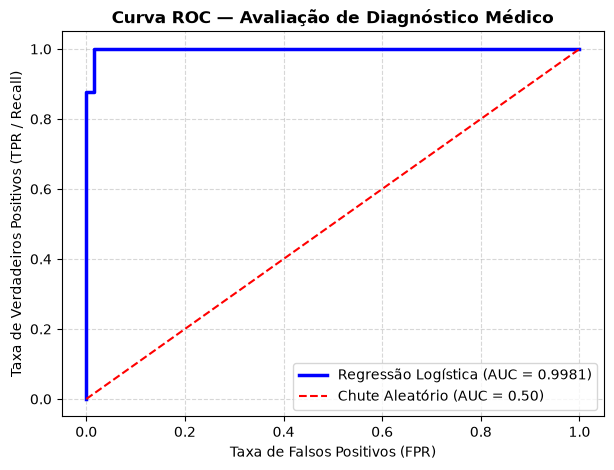

In [7]:
# 1. Definimos as dimensões da figura do gráfico
plt.figure(figsize=(7, 5))

# 2. Desenhamos a Curva ROC azul do modelo e a linha vermelha pontilhada do chute aleatório
plt.plot(taxa_falsos_positivos, taxa_verdadeiros_positivos, color='blue', linewidth=2.5, label=f'Regressão Logística (AUC = {pontuacao_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Chute Aleatório (AUC = 0.50)')

# 3. Adicionamos rótulos e legendas explicativas ao gráfico
plt.title("Curva ROC — Avaliação de Diagnóstico Médico", fontweight='bold')
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR / Recall)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Renderizamos o gráfico no notebook
print("🎨 Exibindo o gráfico da Curva ROC no Colab...")
plt.show()

---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere o número de dobras da Validação Cruzada abaixo e veja como a média se comporta:

1. **Altere as dobras:** Na linha `quantidade_dobras_k = 5`, mude para `3`, `8` ou `10`.
2. **Re-execute e observe:** Veja como o desvio padrão varia de acordo com a quantidade de dobras escolhida por você!

In [8]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 1. Geramos dados bancários simulados reproduzíveis
np.random.seed(88)
n = 150
renda = np.random.uniform(2000, 15000, size=n)
divida = np.random.uniform(500, 50000, size=n)
inadimplente = ((divida / renda) > 3.0).astype(int)

df_banco = pd.DataFrame({'renda': renda, 'divida': divida, 'inadimplente': inadimplente})
matriz_banco_x = df_banco[['renda', 'divida']].values
vetor_banco_y = df_banco['inadimplente'].values

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE A QUANTIDADE DE DOBRAS K:
# -----------------------------------------------------------------------------
quantidade_dobras_k = 5 # Tente mudar para 3, 8 ou 10 dobras!

# 2. Instanciamos a Floresta Aleatória e executamos a Validação Cruzada calculando AUC
floresta_banco = RandomForestClassifier(n_estimators=50, random_state=88)
pontuacoes_auc_dobras = cross_val_score(
    floresta_banco, 
    matriz_banco_x, 
    vetor_banco_y, 
    cv=quantidade_dobras_k, 
    scoring='roc_auc'
)

# 3. Exibimos os relatórios da sua experimentação
print(f"--- RESULTADO DA SUA VALIDAÇÃO CRUZADA ({quantidade_dobras_k}-FOLD) ---")
print(f"Pontuações AUC nas {quantidade_dobras_k} dobras: {pontuacoes_auc_dobras.round(4)}")
print(f"📊 Pontuação AUC Média Final: {pontuacoes_auc_dobras.mean():.4f} ± {pontuacoes_auc_dobras.std():.4f}")

--- RESULTADO DA SUA VALIDAÇÃO CRUZADA (5-FOLD) ---
Pontuações AUC nas 5 dobras: [1.     1.     1.     1.     0.9911]
📊 Pontuação AUC Média Final: 0.9982 ± 0.0036


---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — O Robô que Afina o Seu Modelo (GridSearchCV)**  
> Uma Random Forest tem dezenas de 'botões' reguláveis: `n_estimators`, `max_depth`, `min_samples_split`. Ficar mudando um por um no código e esperando o resultado é cansativo e ineficiente. Na **Aula 11**, aprenderemos o **GridSearchCV** e o **RandomizedSearchCV**: entregamos uma lista de opções e o Python testa todas as combinações automaticamente, nos devolvendo o modelo campeão configurado!
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Se você tiver 3 opções para o botão A, 4 opções para o botão B e rodar um K-Fold com 5 folds, quantos modelos o computador terá que treinar no total? Faça a conta de multiplicação ($3 \times 4 \times 5$)!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi as limitações de confiar em uma única divisão treino/teste.
- [ ] Sei implementar a Validação Cruzada K-Fold com `cross_val_score`.
- [ ] Entendi como interpretar a Média e o Desvio Padrão das dobras da Validação Cruzada.
- [ ] Sei plotar e interpretar a Curva ROC e a métrica AUC (Area Under Curve).
- [ ] Consigo alterar a quantidade de dobras no script e observar a variação.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 3: Validação Cruzada e Curvas ROC).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 10: Validação Cruzada Estratificada e Curvas ROC/AUC

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *Breast Cancer Wisconsin Dataset* (Classificação probabilística de tumores)

---

## 🎯 Objetivo do Laboratório
Garantir a avaliação estatisticamente robusta de modelos preditivos: executar **Validação Cruzada 5-Fold Stratified**, extrair probabilidades reais com `.predict_proba()`, calcular as taxas de Falso Positivo e Verdadeiro Positivo com `roc_curve` e plotar o gráfico comparativo da **Curva ROC** com cálculo de **AUC**.

---

### Passo 1 — Validação Cruzada K-Fold com Múltiplos Folds

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# 1. Carregamos os dados médicos
X, y = load_breast_cancer(return_X_y=True)

# 2. Criamos o pipeline com Scaler + Regressão Logística para evitar data leakage
pipeline_lr = make_pipeline(StandardScaler(), LogisticRegression())

# 3. Executamos 5-Fold Cross Validation estratificado
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(pipeline_lr, X, y, cv=kfold, scoring='accuracy')

print("--- RESULTADOS DA VALIDAÇÃO CRUZADA (5 FOLDS) ---")
print(f"Notas de cada fold: {np.round(scores_lr * 100, 2)}")
print(f"Acurácia Média:     {scores_lr.mean() * 100:.2f}% (± {scores_lr.std() * 100:.2f}%)")

--- RESULTADOS DA VALIDAÇÃO CRUZADA (5 FOLDS) ---
Notas de cada fold: [97.37 94.74 96.49 99.12 99.12]
Acurácia Média:     97.37% (± 1.66%)


---

### Passo 2 — Extraindo Probabilidades Contínuas no Teste

In [10]:
from sklearn.model_selection import train_test_split

# 1. Divisão simples para cálculo da Curva ROC
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

modelo_lr = LogisticRegression()
modelo_lr.fit(X_train_s, y_train)

# 2. Extraímos as probabilidades da classe 1 (Benigno)
probabilidades = modelo_lr.predict_proba(X_test_s)[:, 1]
print("5 primeiras probabilidades estimadas pelo modelo:")
print(np.round(probabilidades[:5], 4))

5 primeiras probabilidades estimadas pelo modelo:
[0.0321 0.9501 0.9835 0.0011 0.2853]


---

### Passo 3 — Plotagem da Curva ROC e Cálculo da AUC

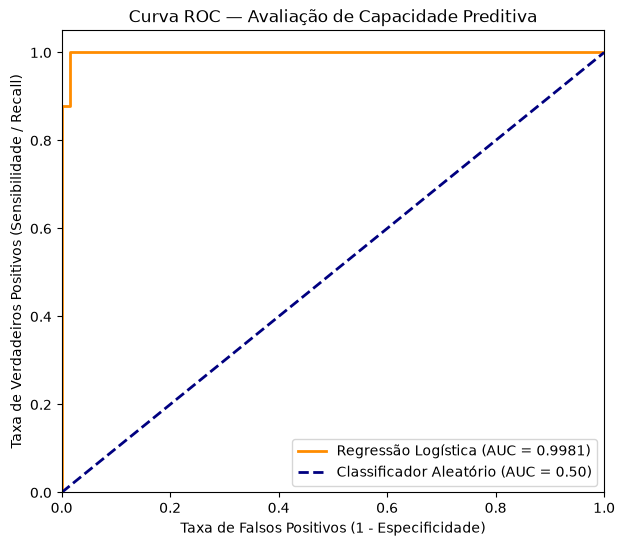

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculamos Taxa de Falsos Positivos (FPR) e Verdadeiros Positivos (TPR)
fpr, tpr, limiares = roc_curve(y_test, probabilidades)
auc_score = roc_auc_score(y_test, probabilidades)

# 2. Plotamos a Curva ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Regressão Logística (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
plt.title('Curva ROC — Avaliação de Capacidade Preditiva')
plt.legend(loc="lower right")
plt.show()

---

## 🏆 Desafio Técnico de Validação
Treine um modelo `RandomForestClassifier` no mesmo conjunto e plote a Curva ROC dele na mesma figura para descobrir qual modelo alcançou maior pontuação AUC.

In [12]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
